In [1]:
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [91]:
file_name_list = os.listdir(os.path.join('data', 'test_data'))

target_data = '20251117'
data_list = []

for file_name in file_name_list:
    if target_data in file_name:
        file_path = os.path.join('data', 'test_data', file_name)
        data = pd.read_csv(file_path)
        data_list.append(data)

In [92]:
data_index = 4

data = data_list[data_index]
data = data.iloc[::2]

data = data[data['venturi_flowrate(lpm)'] > 0]
data = data[data['estimation_flowrate(lpm)'] > 0]
data.reset_index(inplace=True, drop=True)

In [93]:
data.columns

Index(['Unnamed: 0', 'time(sec)', 'pump_inlet_pressure(bar)',
       'pump_outlet_pressure(bar)', 'pump_speed(rpm)', 'venturi_flowrate(lpm)',
       'estimation_flowrate(lpm)'],
      dtype='object')

Text(0, 0.5, 'Pressure(bar)')

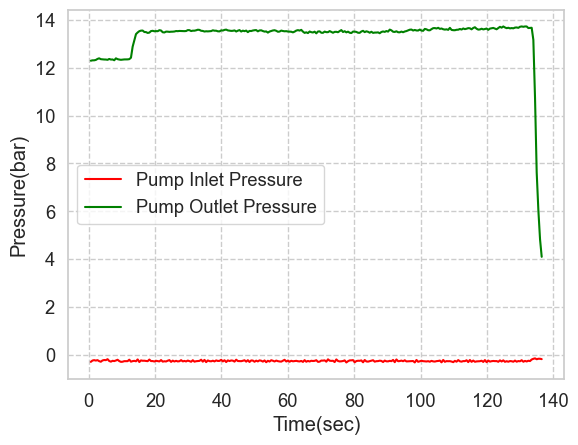

In [94]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=data, x='time(sec)', y='pump_inlet_pressure(bar)', color='red', label='Pump Inlet Pressure')
sns.lineplot(data=data, x='time(sec)', y='pump_outlet_pressure(bar)', color='green', label='Pump Outlet Pressure')

plt.xlabel('Time(sec)')
plt.ylabel('Pressure(bar)')

Text(0, 0.5, 'Pump Speed(RPM)')

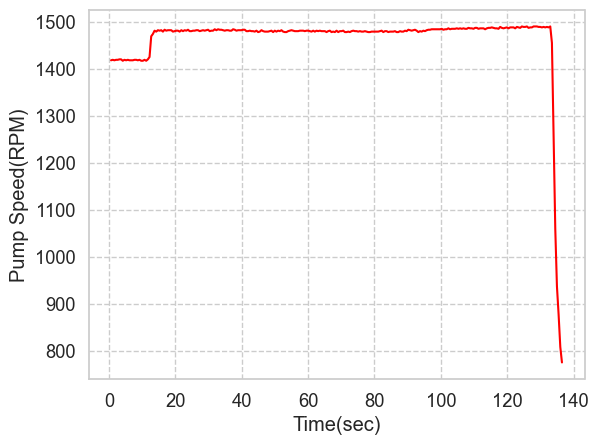

In [95]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=data, x='time(sec)', y='pump_speed(rpm)', color='red')

plt.xlabel('Time(sec)')
plt.ylabel('Pump Speed(RPM)')

136.493


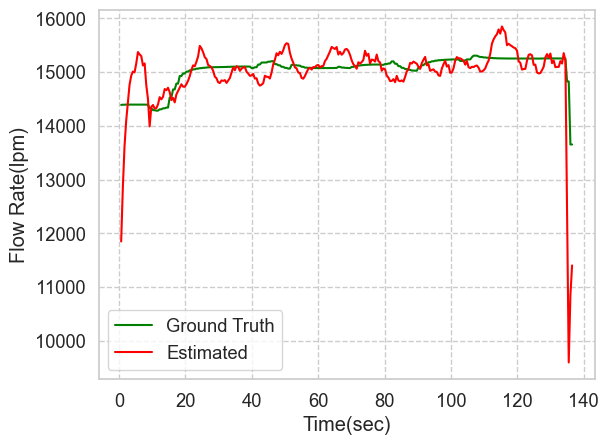

In [96]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=data, x='time(sec)', y='venturi_flowrate(lpm)', color='green', label='Ground Truth')
sns.lineplot(data=data, x='time(sec)', y='estimation_flowrate(lpm)', color='red', label='Estimated')

plt.xlabel('Time(sec)')
plt.ylabel('Flow Rate(lpm)')

print(data['time(sec)'].iloc[data.shape[0]-1])

253.70799705014758


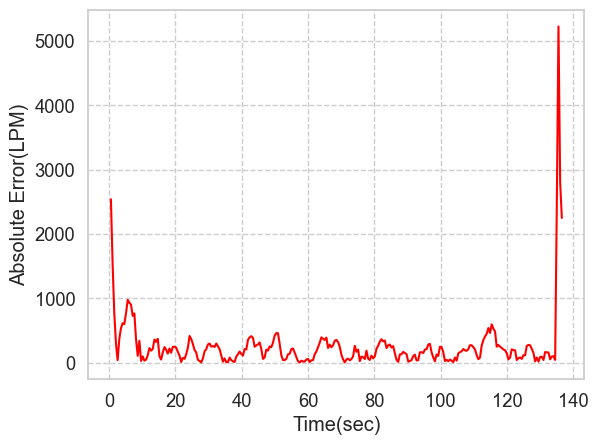

In [97]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

abs_error = (np.abs(data['venturi_flowrate(lpm)'] - data['estimation_flowrate(lpm)']))
relative_error = (abs_error / (data['venturi_flowrate(lpm)'])) * 100

sns.lineplot(data=data, x='time(sec)', y=abs_error, color='red')

plt.xlabel('Time(sec)')
plt.ylabel('Absolute Error(LPM)')

print(np.mean(abs_error))

1.7108109378036964


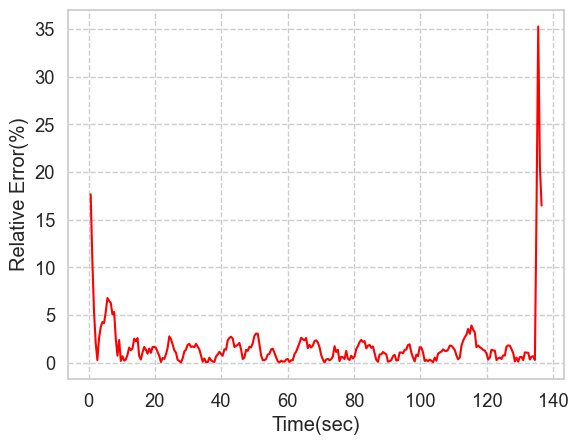

In [98]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=data, x='time(sec)', y=relative_error, color='red')

plt.xlabel('Time(sec)')

#plt.yscale('log')
plt.ylabel('Relative Error(%)')

print(np.mean(relative_error))

In [9]:
file_name_list = os.listdir(os.path.join('data', 'period_data'))

data_list = []

for file_name in file_name_list:
    file_path = os.path.join('data', 'period_data', file_name)
    data = pd.read_csv(file_path)
    data_list.append(data)

In [10]:
data_index = 4

edge_arr = np.diff(data_list[data_index]['state'])
edge_arr = np.concatenate([np.array([0]), edge_arr], axis=0)

period_time_arr = []
t0 = 0

for i, arr in enumerate(edge_arr):

    if arr == 1:
        t0 = data_list[data_index]['time(sec)'].iloc[i]

    if arr == -1:
        period_time = data_list[data_index]['time(sec)'].iloc[i] - t0
        period_time_arr.append(period_time)
        t0 = 0

period_time_arr = np.array(period_time_arr)*1000

print(period_time_arr.shape)

(375,)


188.639


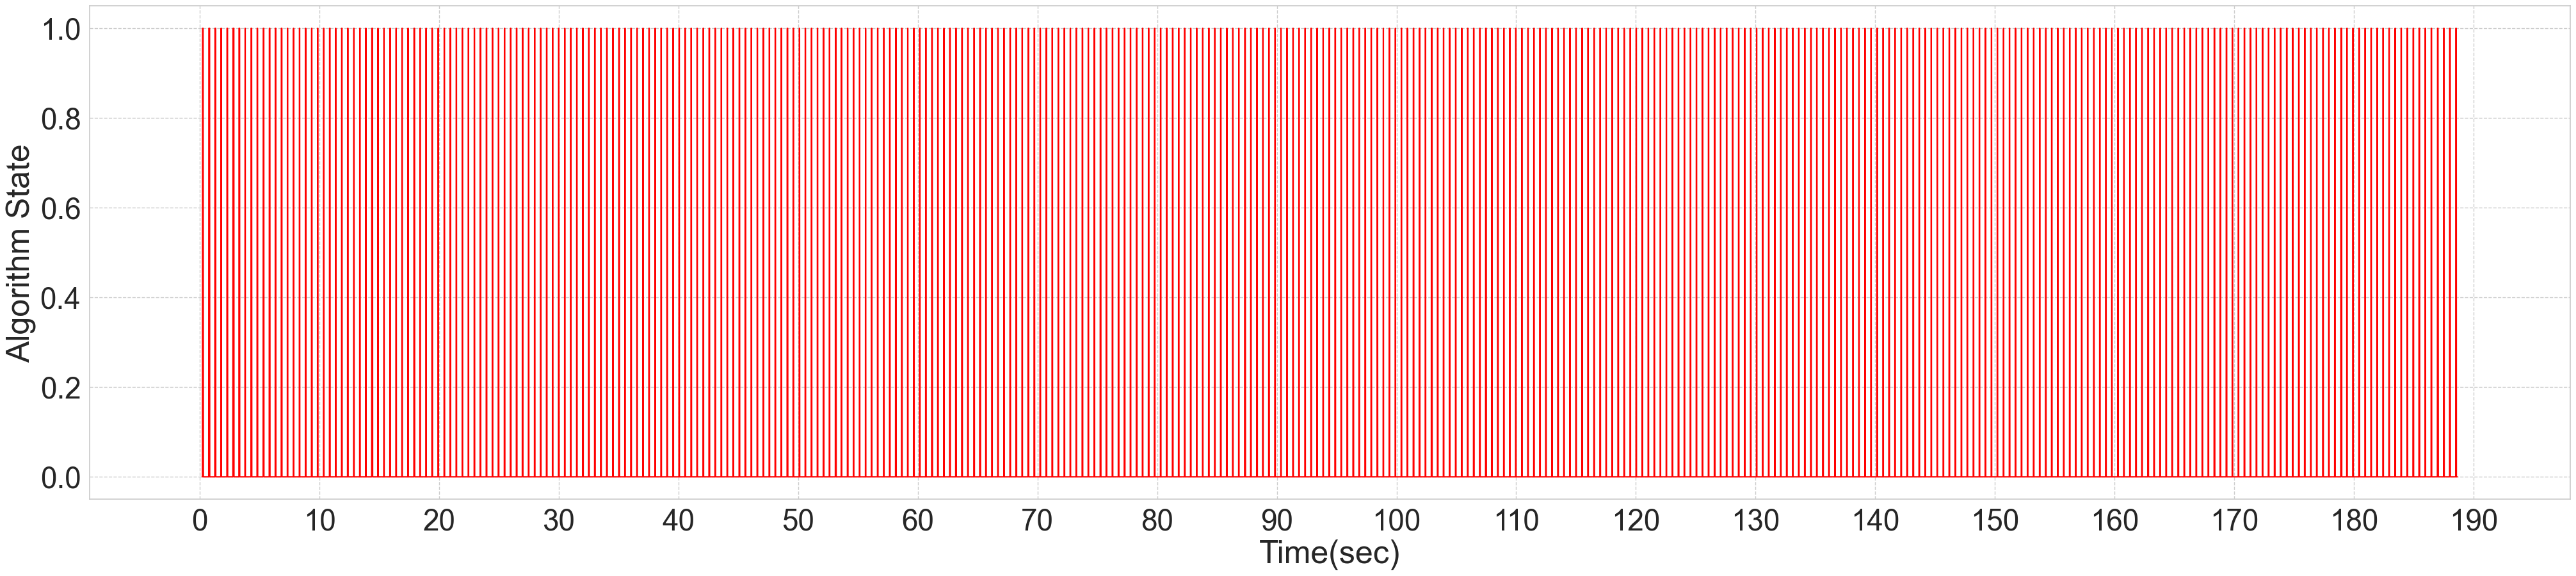

In [11]:
sns.set_theme(font_scale=3)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.figure(figsize=(50, 10))

data = data_list[data_index]

axis = sns.lineplot(data=data, x='time(sec)', y='state', color='red')

axis.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.xlabel('Time(sec)')

plt.ylabel('Algorithm State')
print(data['time(sec)'].iloc[data.shape[0]-1])

Text(0, 0.5, 'Algorithm State')

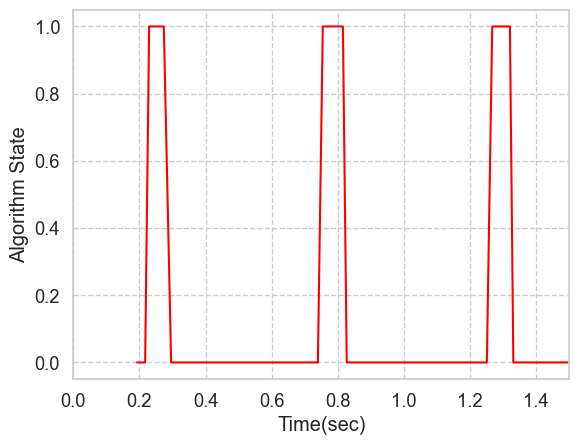

In [12]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

data = data_list[data_index]

axis = sns.lineplot(data=data, x='time(sec)', y='state', color='red')

plt.xlabel('Time(sec)')
plt.xlim(0, 1.5)

plt.ylabel('Algorithm State')

36.9405333333328 8.577931979730558


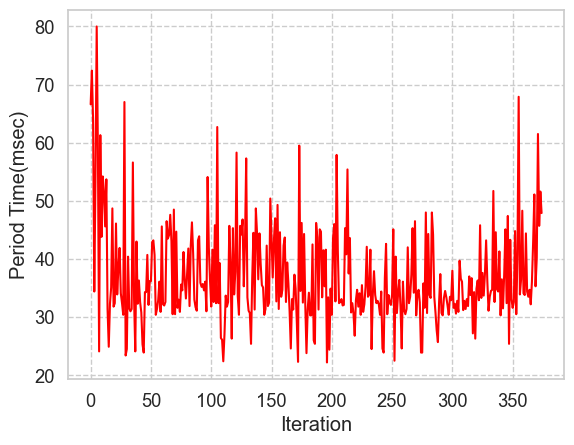

In [13]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(period_time_arr, color='red')

plt.xlabel('Iteration')
plt.ylabel('Period Time(msec)')

print(np.mean(period_time_arr), np.std(period_time_arr))